<a href="https://colab.research.google.com/github/Pranayshukla0610/MLFlow/blob/main/Credit_Risk_Scoring_using_Logistic_Regression_%26_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import shap

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [5]:
df['Purpose'].value_counts()

,count
Purpose,
car,337
radio/TV,280
furniture/equipment,181
business,97
education,59
repairs,22
domestic appliances,12
vacation/others,12


In [6]:
df['Housing'].value_counts()

,count
Housing,
own,713
rent,179
free,108


In [11]:
df['Sex'].value_counts()

,count
Sex,
male,690
female,310


In [12]:
df['Job'].value_counts()

,count
Job,
2,630
1,200
3,148
0,22


In [7]:
df.shape

(1000, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [9]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [13]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [15]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [16]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [17]:
df['Risk'] = np.where(
    (df['Credit amount'] > 4000) &
    (df['Duration'] > 24),
    1,0
)

In [18]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,0


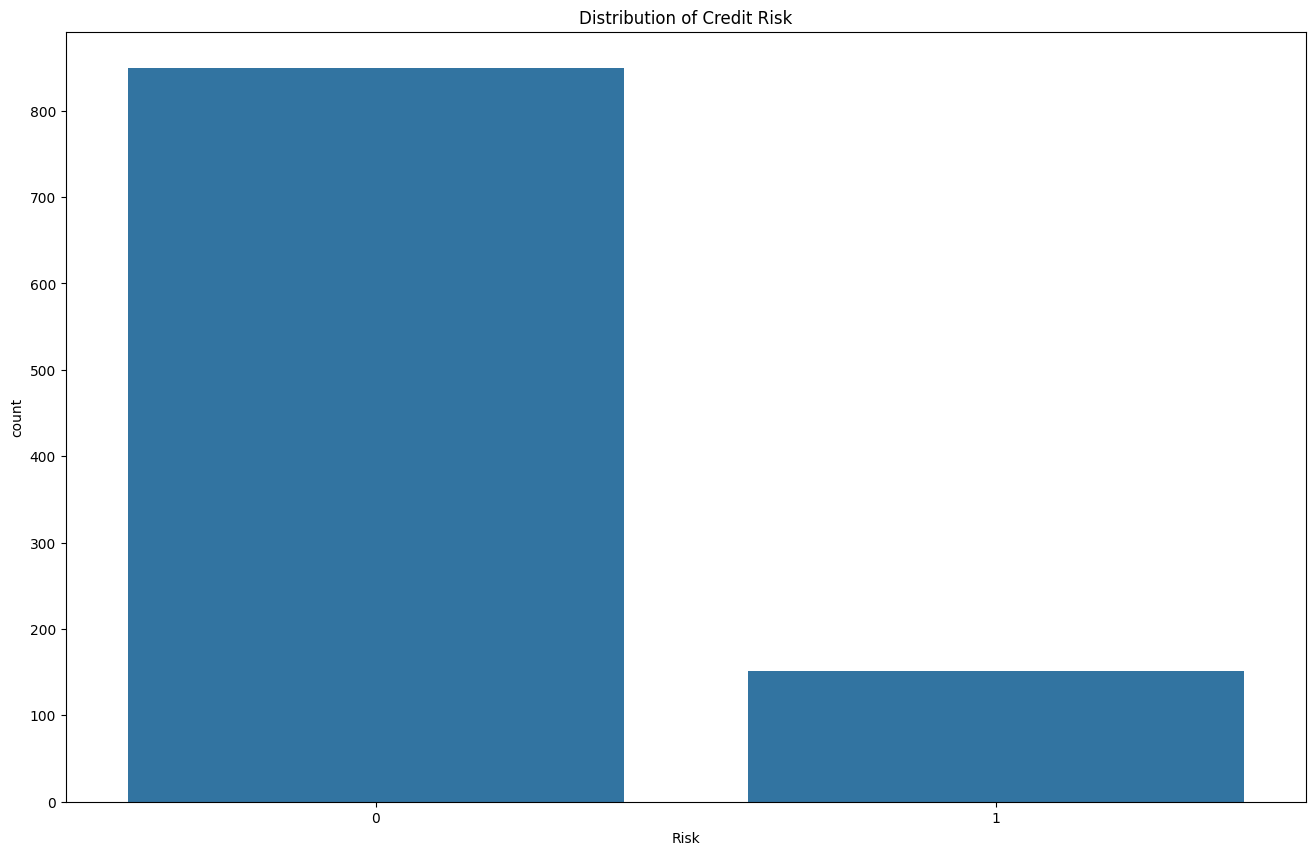

In [20]:
plt.figure(figsize=(16,10))
sns.countplot(x ='Risk',data=df)
plt.title('Distribution of Credit Risk')
plt.show()

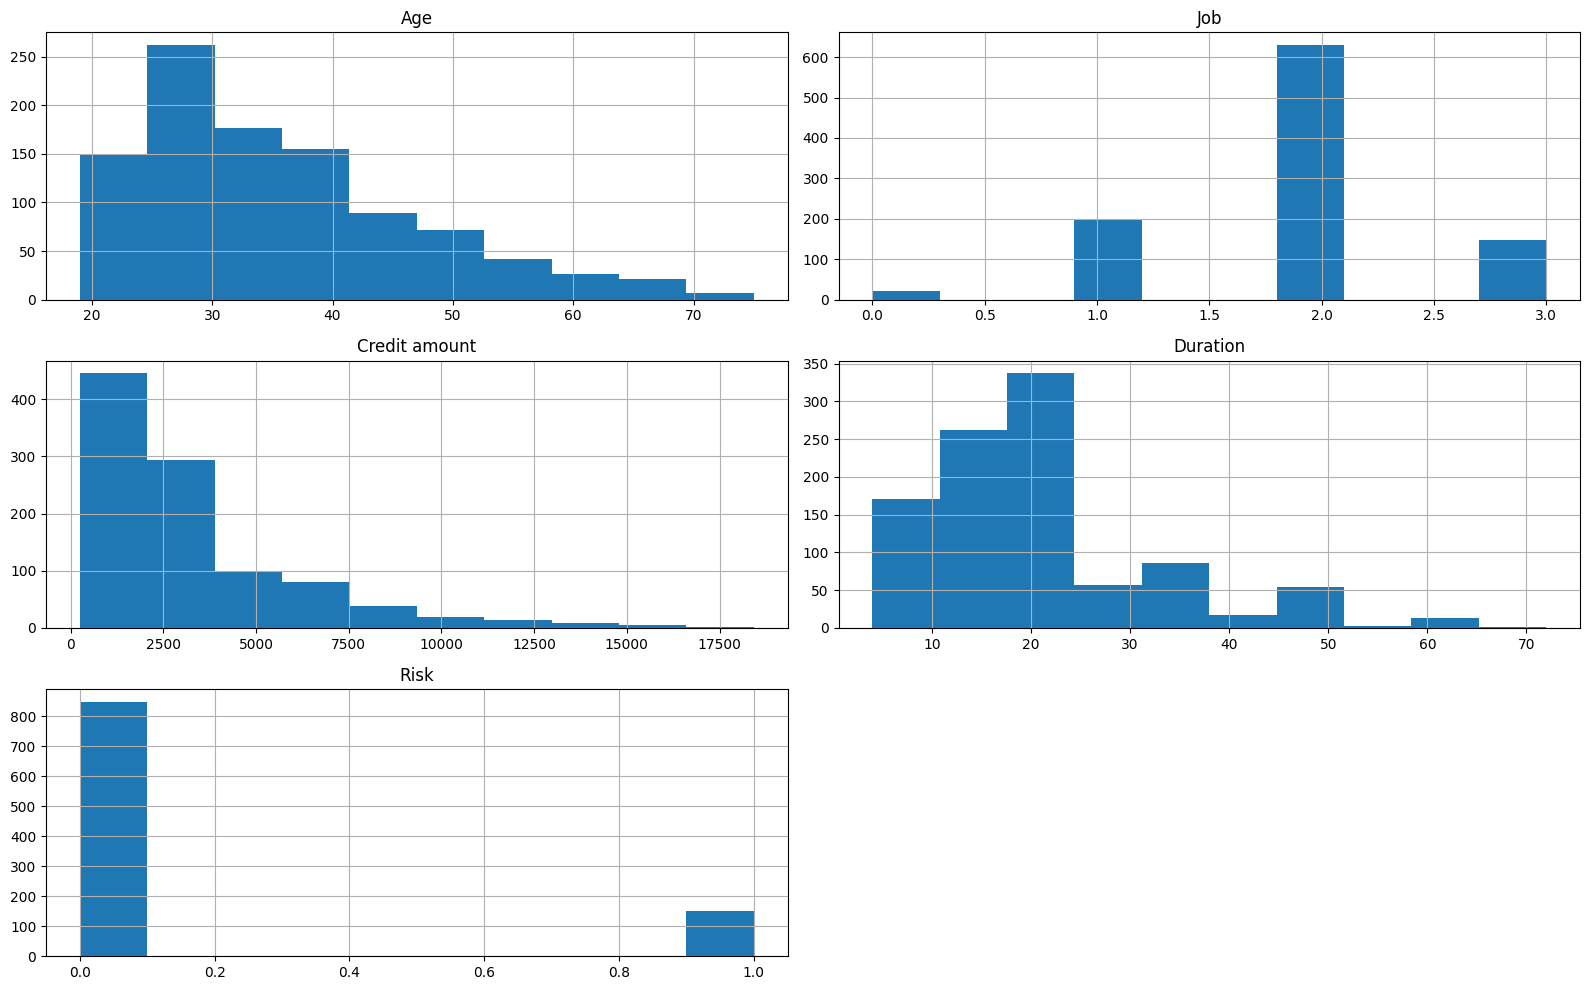

In [21]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(16,10))
plt.tight_layout()
plt.show()

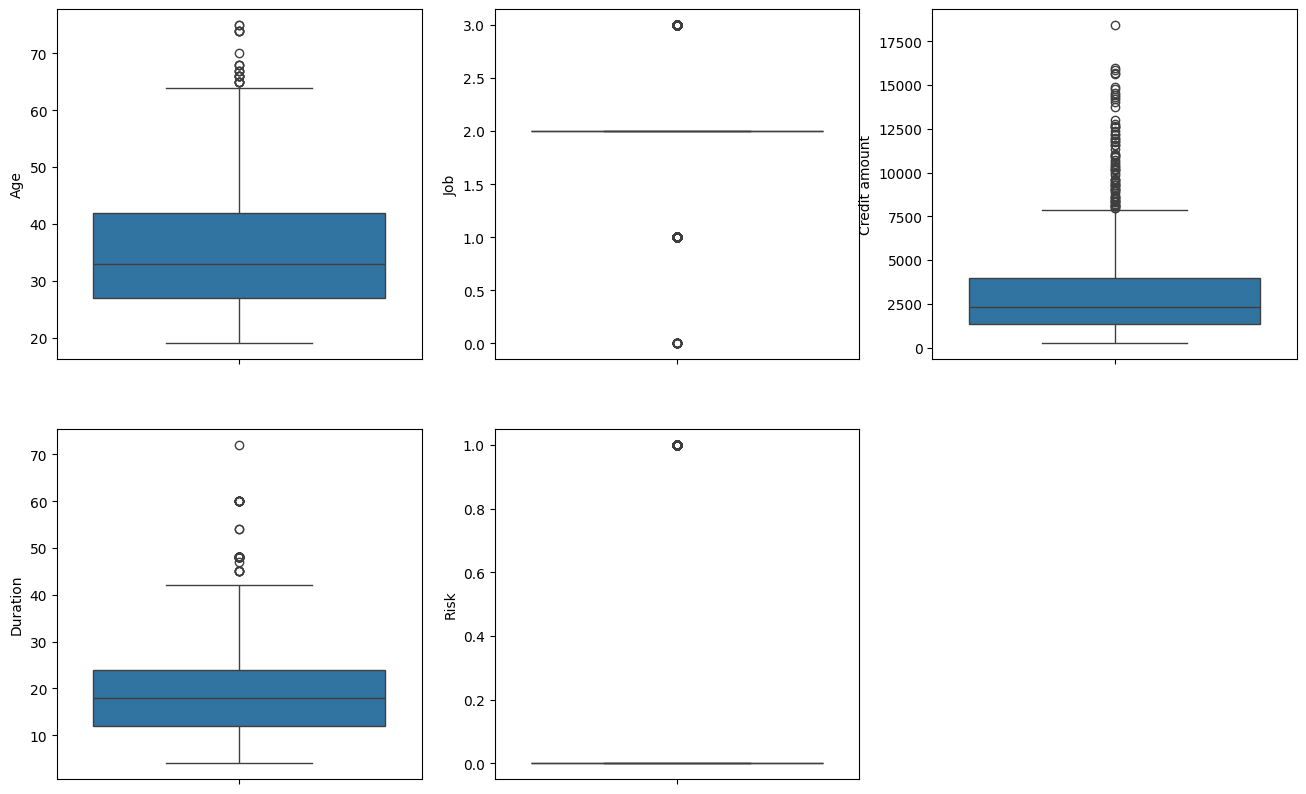

In [22]:
plt.figure(figsize=(16,10))
for i, col in enumerate(num_cols):
  plt.subplot(2,3,i+1)
  sns.boxplot(y=df[col])

plt.show()

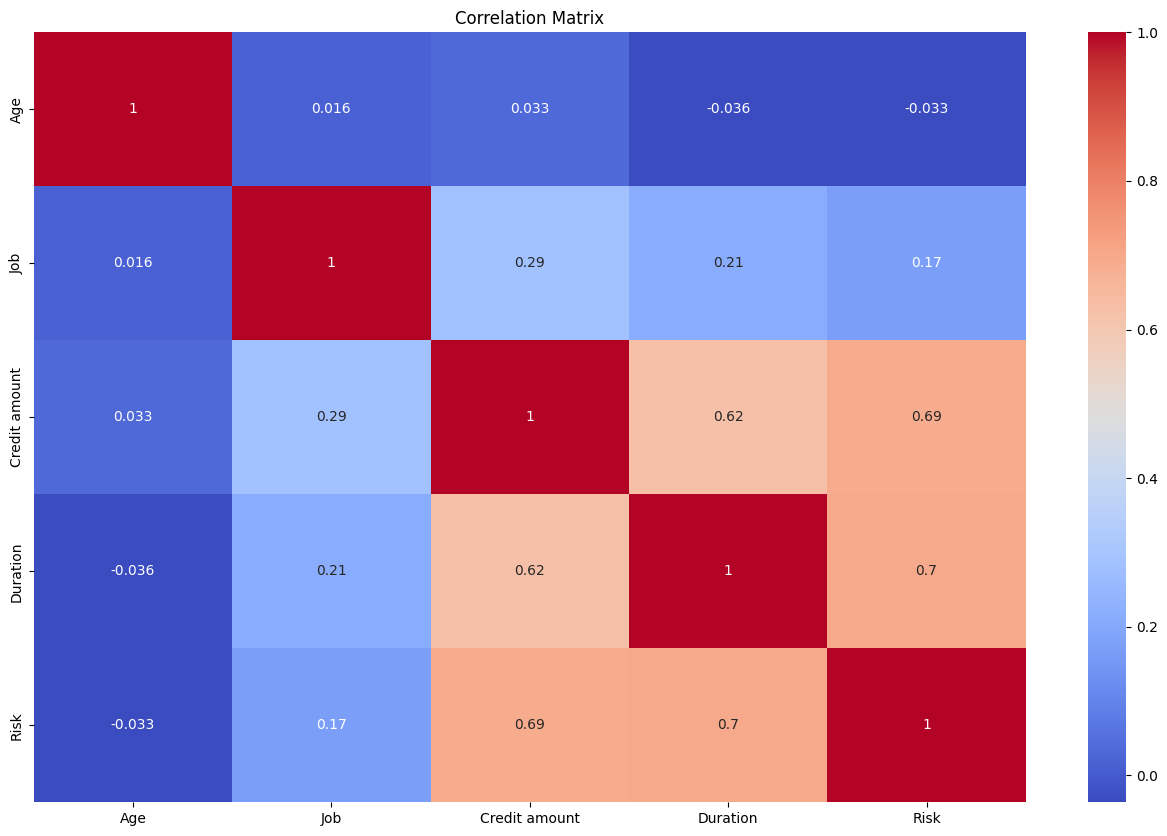

In [23]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(numeric_only=True),
            annot = True,
            cmap = 'coolwarm')

plt.title('Correlation Matrix')
plt.show()

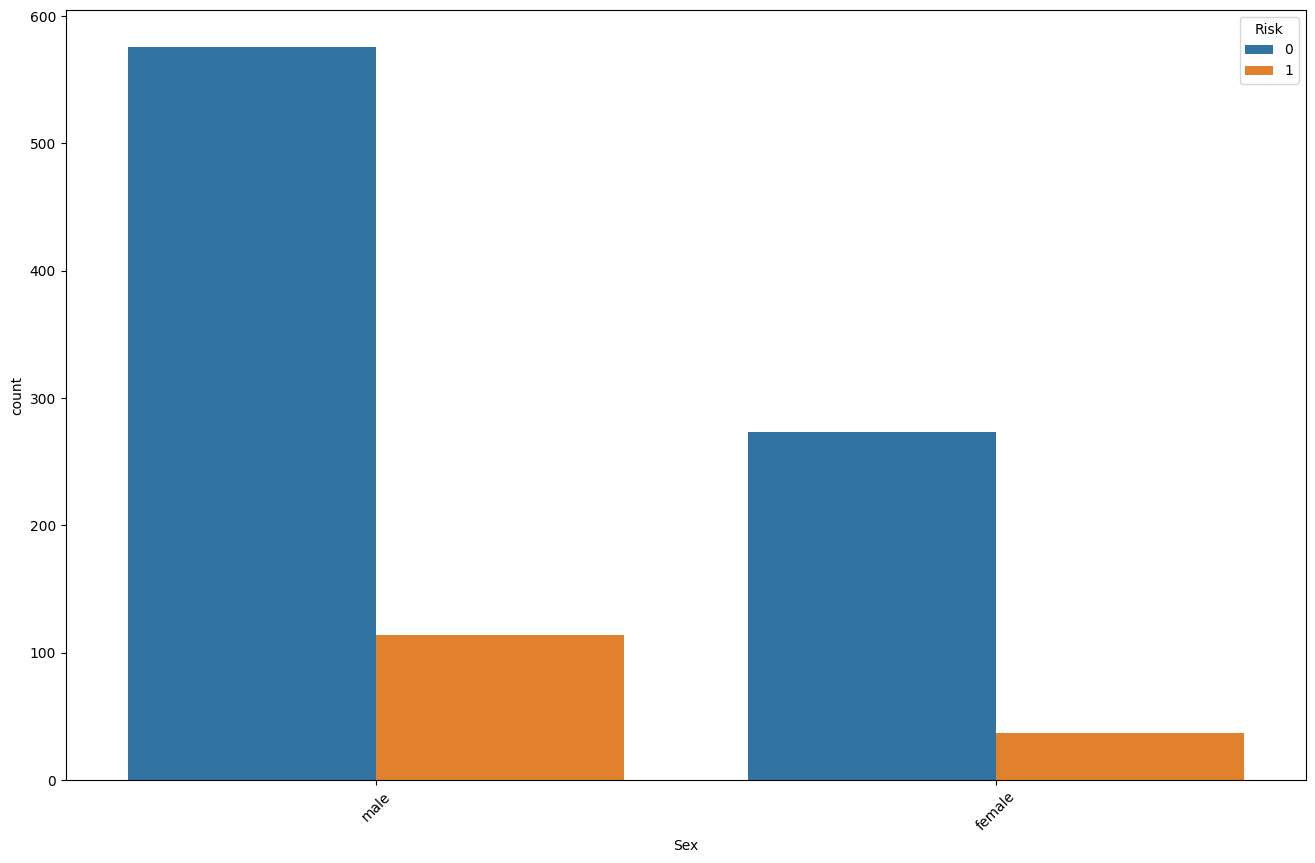

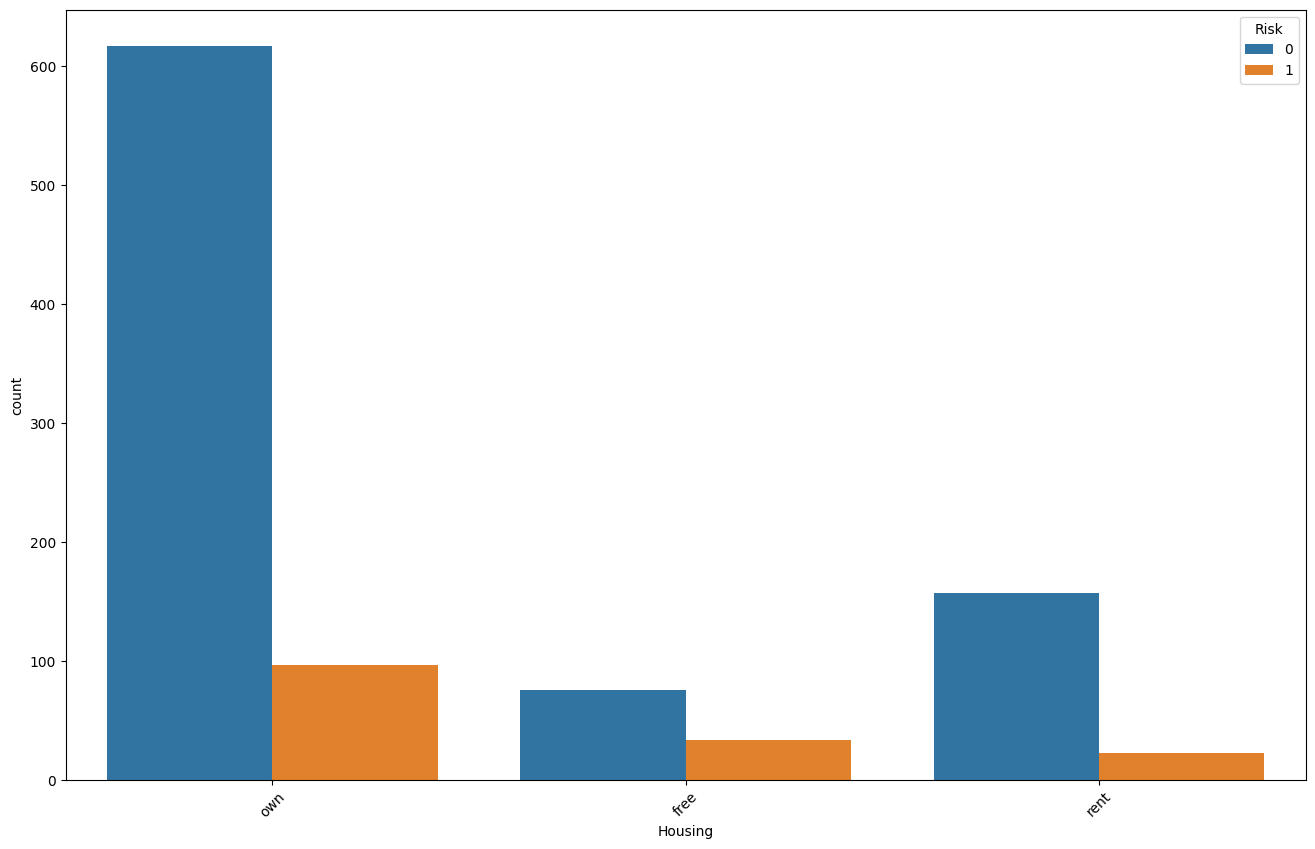

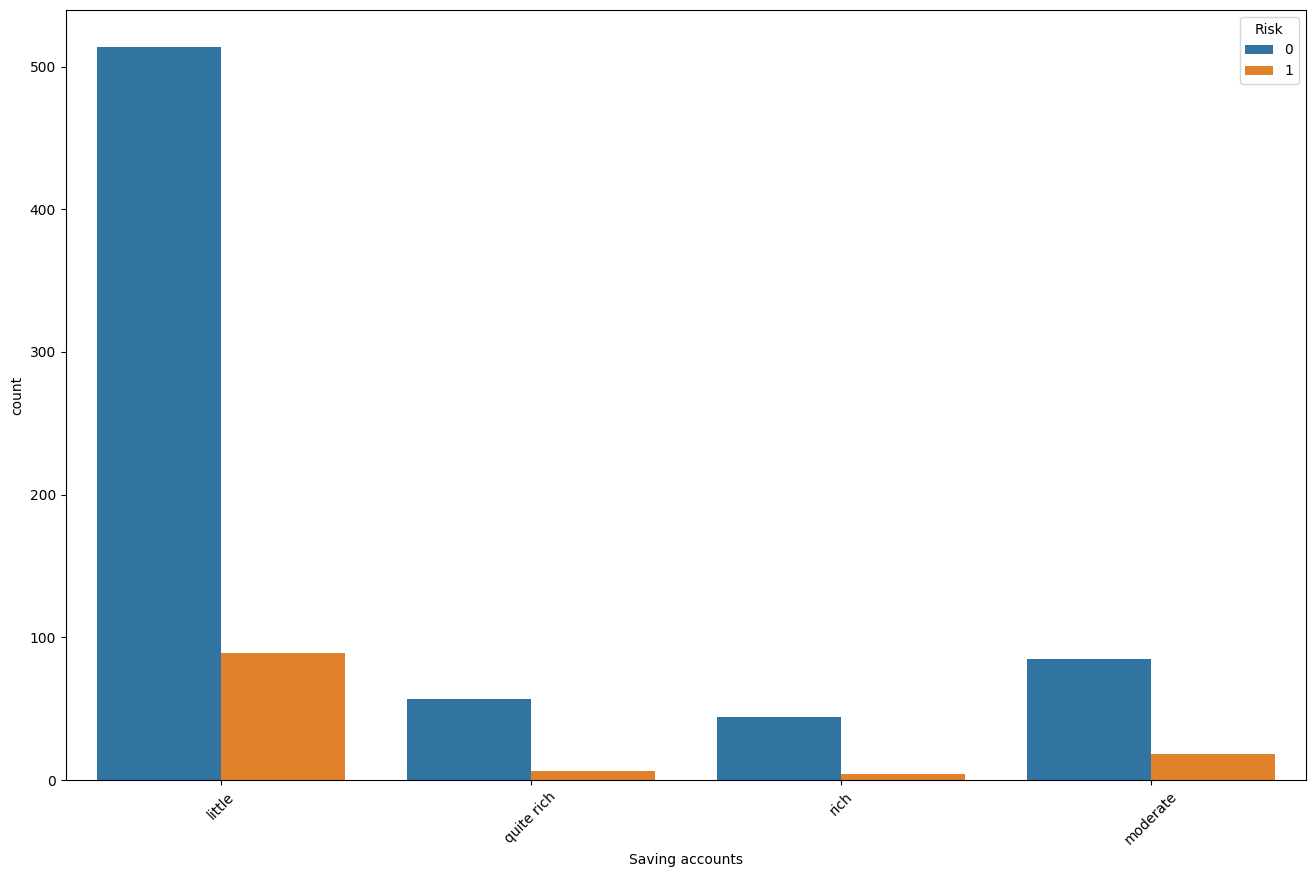

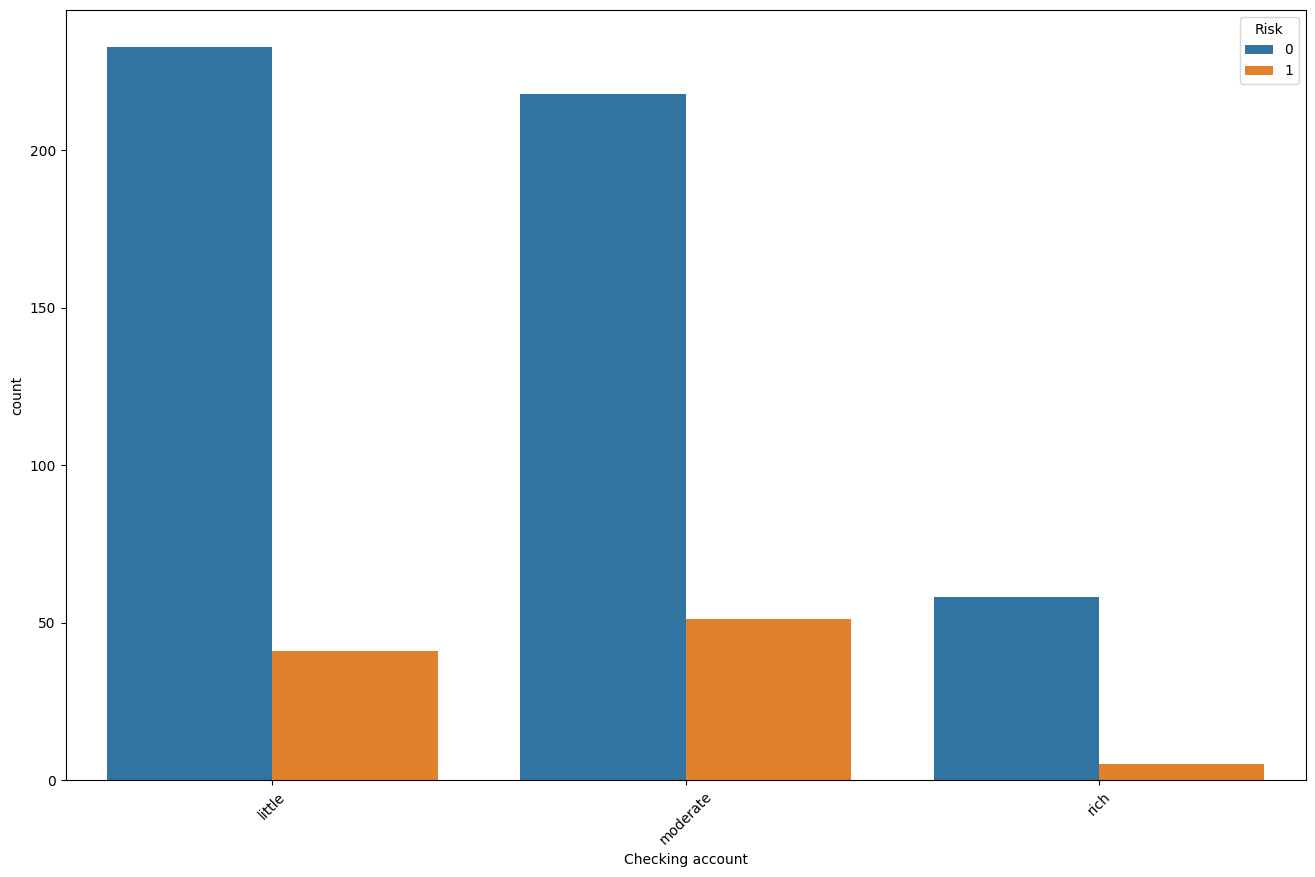

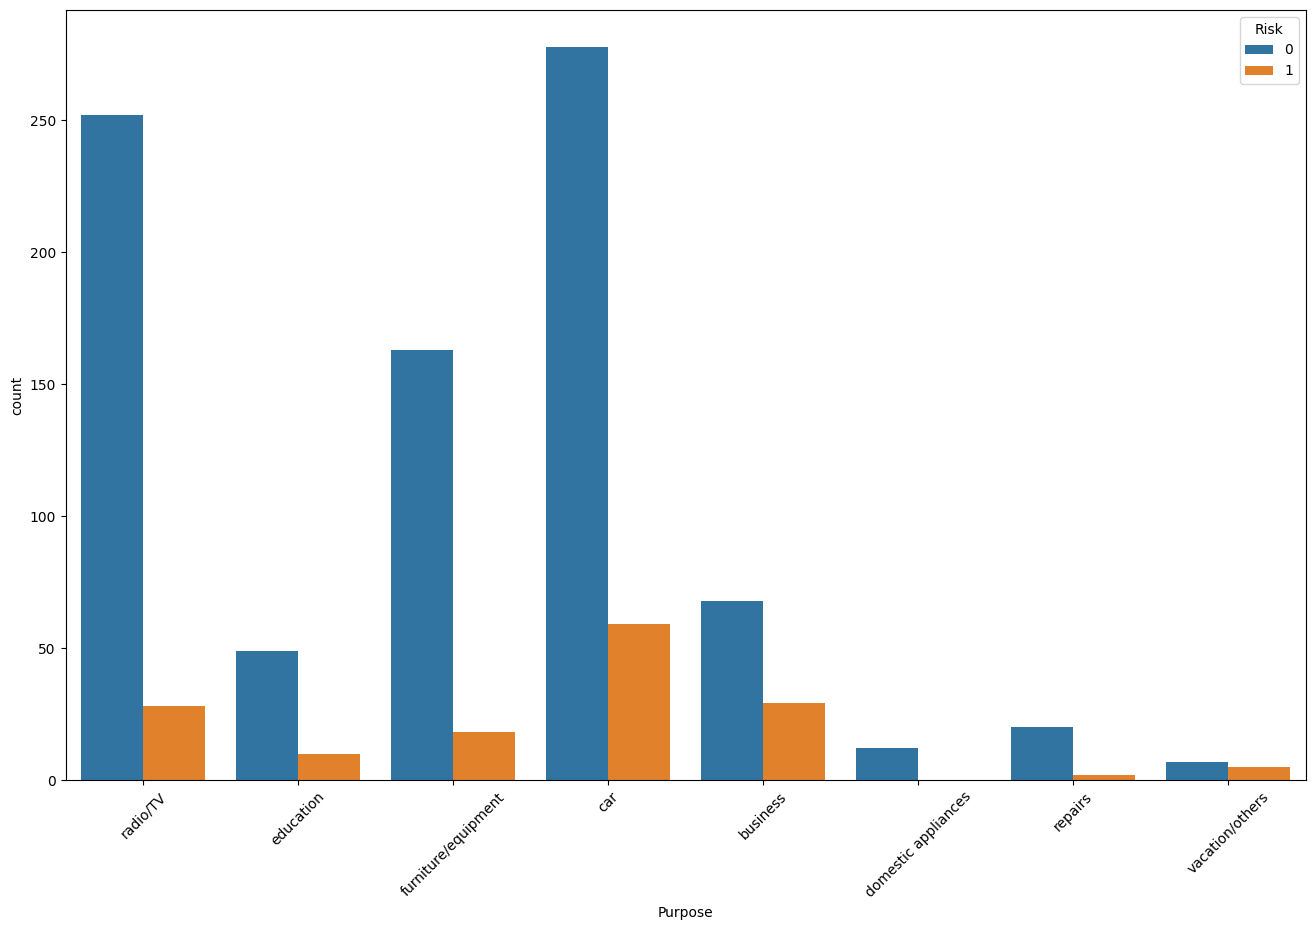

In [24]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
  plt.figure(figsize=(16,10))
  sns.countplot(x=col, hue='Risk', data=df)
  plt.xticks(rotation=45)
  plt.show()

In [25]:
df.fillna(df.mode().iloc[0],inplace=True)

In [26]:
le = LabelEncoder()

for col in cat_cols:
  df[col] = le.fit_transform(df[col])

In [27]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,0,1169,6,5,0
1,22,0,2,1,0,1,5951,48,5,1
2,49,1,1,1,0,0,2096,12,3,0
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


In [28]:
X = df.drop('Risk',axis=1)
y = df['Risk']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

log_model_pred = log_model.predict(X_test_scaled)

In [34]:
coefficients = pd.DataFrame({
    'Feature':X.columns,
    'Coefficients':log_model.coef_[0]
})

coefficients.sort_values(by='Coefficients', ascending=False)


,Feature,Coefficients
7,Duration,2.657228
6,Credit amount,1.801618
3,Housing,0.244906
2,Job,0.038133
5,Checking account,0.035248
4,Saving accounts,0.013548
1,Sex,0.009759
8,Purpose,-0.181300
0,Age,-0.400978


In [35]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [37]:
print("Logistic Accuracy:",
      accuracy_score(y_test, log_model_pred))

print("XGB Accuracy:",
      accuracy_score(y_test, xgb_pred))

Logistic Accuracy: 0.945
XGB Accuracy: 1.0


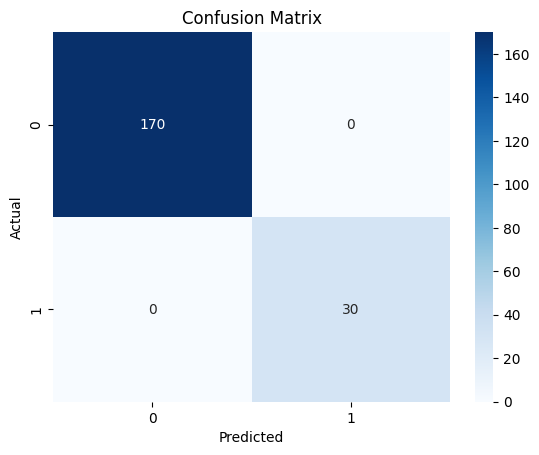

In [38]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()